# Paso B: Estadisticas geometricas de los espacios vectoriales

Comparamos la estructura geometrica de los embeddings FR vs ES en cada nivel:
1. **Normas de vectores** — magnitud promedio, distribucion
2. **Distancias intra-espacio** — que tan dispersos estan los vectores
3. **Isotropy** — que tan uniformemente se distribuyen las direcciones en el espacio
4. **Similaridad coseno intra-espacio** — self-similarity promedio (alta = espacio colapsado, baja = buena distribucion)

In [1]:
import sys
sys.path.insert(0, ".")

from loader import load_all_models, get_vocab, PHONEME_INVENTORY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist

models = load_all_models()
print("Models loaded.")

Models loaded.


In [2]:
def get_filtered_vectors(model, lang=None):
    """Get vectors for the filtered vocabulary."""
    vocab = get_vocab(model, lang=lang)
    tokens = sorted(vocab)
    vectors = np.array([model.wv[t] for t in tokens])
    return tokens, vectors


def compute_isotropy(vectors):
    """Compute isotropy: how uniformly directions are used in the space.
    
    Based on the partition function of cosine similarities.
    Isotropy = 1 means perfectly uniform use of directions.
    Values close to 0 mean the space is anisotropic (clustered directions).
    
    Mu, Viswanath (2018) - "All-but-the-Top"
    """
    # Use eigenvalues of the covariance matrix
    centered = vectors - vectors.mean(axis=0)
    cov = np.cov(centered.T)
    eigenvalues = np.linalg.eigvalsh(cov)
    eigenvalues = eigenvalues[eigenvalues > 0]
    # Isotropy as ratio of min to max eigenvalue (1 = isotropic)
    return eigenvalues.min() / eigenvalues.max()


def compute_stats(model, lang=None):
    """Compute all geometric statistics for a model."""
    tokens, vectors = get_filtered_vectors(model, lang)
    n = len(tokens)
    
    # Norms
    norms = np.linalg.norm(vectors, axis=1)
    
    # Pairwise cosine similarity (sample if too large)
    if n > 2000:
        idx = np.random.RandomState(42).choice(n, 2000, replace=False)
        cos_matrix = cosine_similarity(vectors[idx])
    else:
        cos_matrix = cosine_similarity(vectors)
    # Exclude diagonal
    mask = ~np.eye(cos_matrix.shape[0], dtype=bool)
    cos_vals = cos_matrix[mask]
    
    # Pairwise euclidean distances (sample if too large)
    if n > 2000:
        euc_dists = pdist(vectors[idx], metric="euclidean")
    else:
        euc_dists = pdist(vectors, metric="euclidean")
    
    # Isotropy
    iso = compute_isotropy(vectors)
    
    return {
        "n_tokens": n,
        "norm_mean": norms.mean(),
        "norm_std": norms.std(),
        "norm_min": norms.min(),
        "norm_max": norms.max(),
        "cos_sim_mean": cos_vals.mean(),
        "cos_sim_std": cos_vals.std(),
        "cos_sim_median": np.median(cos_vals),
        "eucl_dist_mean": euc_dists.mean(),
        "eucl_dist_std": euc_dists.std(),
        "isotropy": iso,
    }, norms, cos_vals, euc_dists

## 1. Tabla resumen de estadisticas geometricas

In [3]:
all_stats = {}
all_distributions = {}

for level in ("phoneme", "syllable", "word"):
    for lang in ("es", "fr"):
        lang_filter = lang if level == "phoneme" else None
        stats, norms, cos_vals, euc_dists = compute_stats(models[level][lang], lang=lang_filter)
        key = f"{level}_{lang}"
        all_stats[key] = {"Nivel": level, "Idioma": lang.upper(), **stats}
        all_distributions[key] = {"norms": norms, "cos_vals": cos_vals, "euc_dists": euc_dists}

stats_df = pd.DataFrame(all_stats.values())
stats_df = stats_df.set_index(["Nivel", "Idioma"])
stats_df.round(4)

n_tokens  norm_mean  norm_std  norm_min   norm_max  \
Nivel    Idioma                                                       
phoneme  ES            29     2.7854    1.9726    1.6242   8.585800   
         FR            36     3.0142    1.0759    2.2078   8.449200   
syllable ES          9848     6.4622    4.2743    1.3855  21.324200   
         FR         12433     6.9093    4.8455    1.1726  27.154900   
word     ES         37291    10.9993    3.7625    3.3604  26.746599   
         FR         37269    11.7124    4.2475    2.0597  34.348000   

                 cos_sim_mean  cos_sim_std  cos_sim_median  eucl_dist_mean  \
Nivel    Idioma                                                              
phoneme  ES            0.4525       0.2731          0.4207          3.3853   
         FR            0.5731       0.2758          0.6702          2.8861   
syllable ES            0.1531       0.2195          0.1416          9.3239   
         FR            0.0745       0.1640          0.0539         10.5120   
word     ES            0.0091       0.1378         -0.0060         15.9911   
         FR            0.0105       0.1292         -0.0040         16.9756   

                 eucl_dist_std  isotropy  
Nivel    Idioma                           
phoneme  ES             2.5479    0.0000  
         FR             1.8211    0.0000  
syllable ES             5.0462    0.0007  
         FR             5.5508    0.0008  
word     ES             4.0225    0.0012  
         FR             4.4941    0.0008

## 2. Distribucion de normas de vectores

La magnitud de los vectores indica cuanto "peso" tiene cada token en el espacio. Distribuciones similares entre idiomas sugieren estructuras comparables.

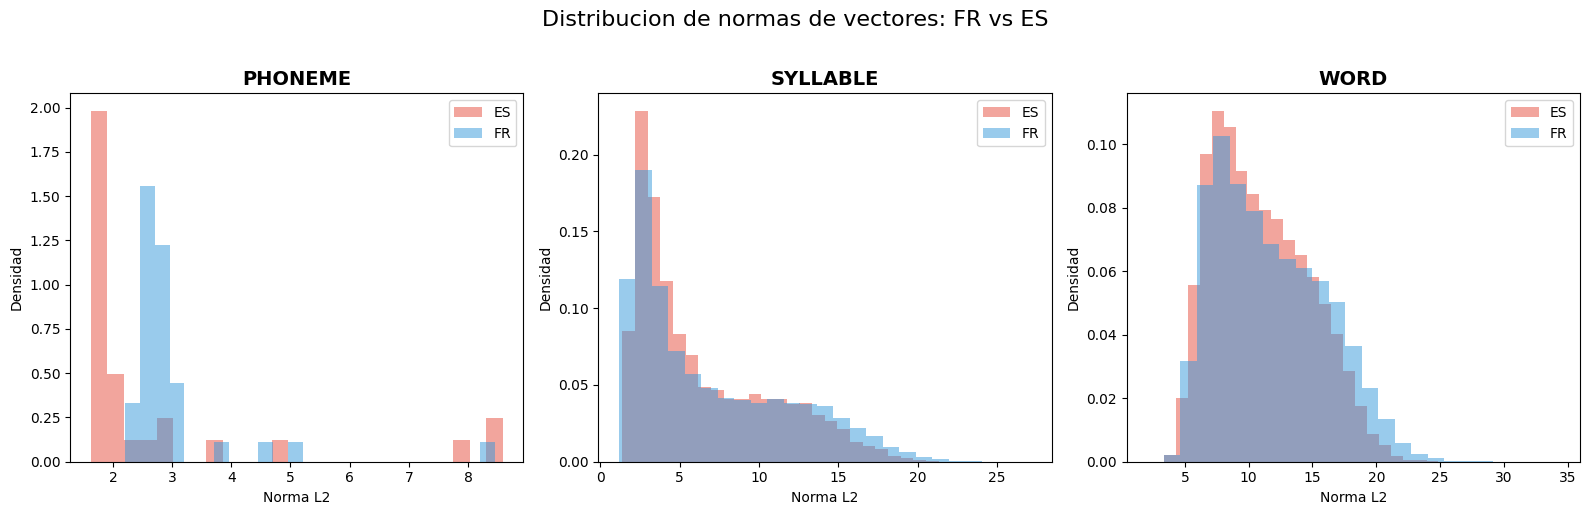

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    for lang, color, label in [("es", "#e74c3c", "ES"), ("fr", "#3498db", "FR")]:
        key = f"{level}_{lang}"
        norms = all_distributions[key]["norms"]
        ax.hist(norms, bins=25, alpha=0.5, color=color, label=label, density=True)
    
    ax.set_xlabel("Norma L2")
    ax.set_ylabel("Densidad")
    ax.set_title(f"{level.upper()}", fontsize=14, fontweight="bold")
    ax.legend()

plt.suptitle("Distribucion de normas de vectores: FR vs ES", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("norm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Distribucion de similaridad coseno intra-espacio

La similaridad coseno promedio entre todos los pares de tokens dentro del mismo espacio. Valores cercanos a 0 indican buena dispersion; valores altos indican que los vectores estan "apretados" en pocas direcciones (anisotropia).

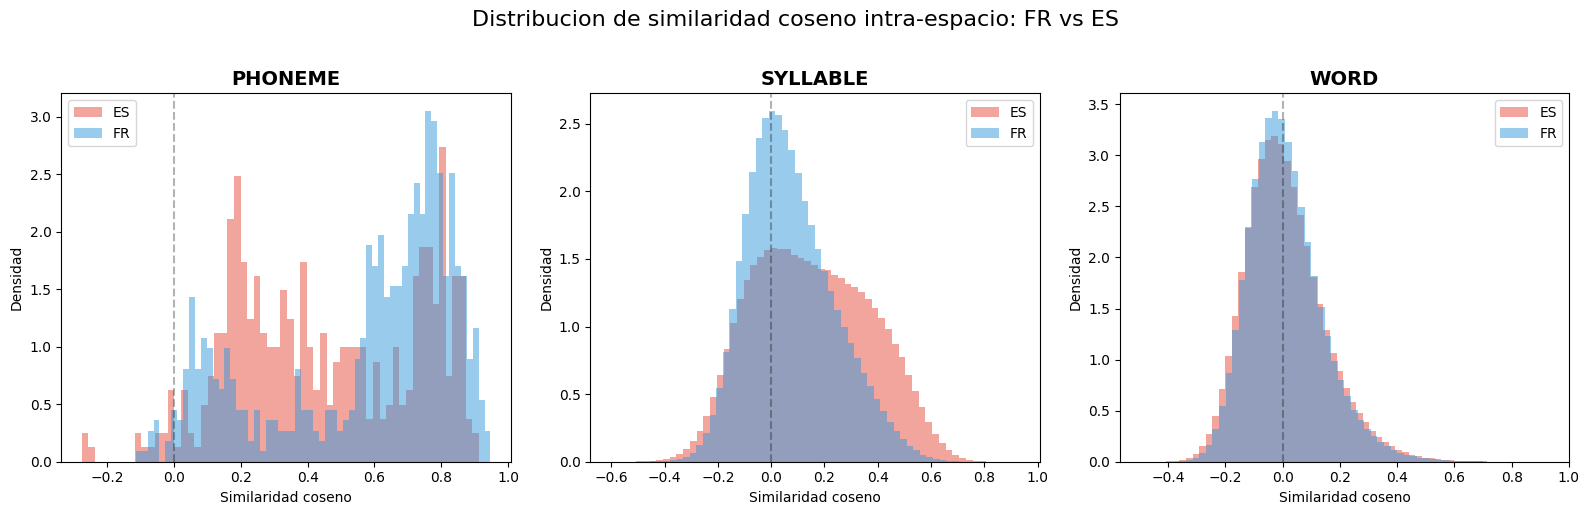

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    for lang, color, label in [("es", "#e74c3c", "ES"), ("fr", "#3498db", "FR")]:
        key = f"{level}_{lang}"
        cos_vals = all_distributions[key]["cos_vals"]
        ax.hist(cos_vals, bins=60, alpha=0.5, color=color, label=label, density=True)
    
    ax.set_xlabel("Similaridad coseno")
    ax.set_ylabel("Densidad")
    ax.set_title(f"{level.upper()}", fontsize=14, fontweight="bold")
    ax.axvline(x=0, color="black", linestyle="--", alpha=0.3)
    ax.legend()

plt.suptitle("Distribucion de similaridad coseno intra-espacio: FR vs ES", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("cosine_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Isotropy y self-similarity comparados

Visualizacion directa de las metricas clave lado a lado.

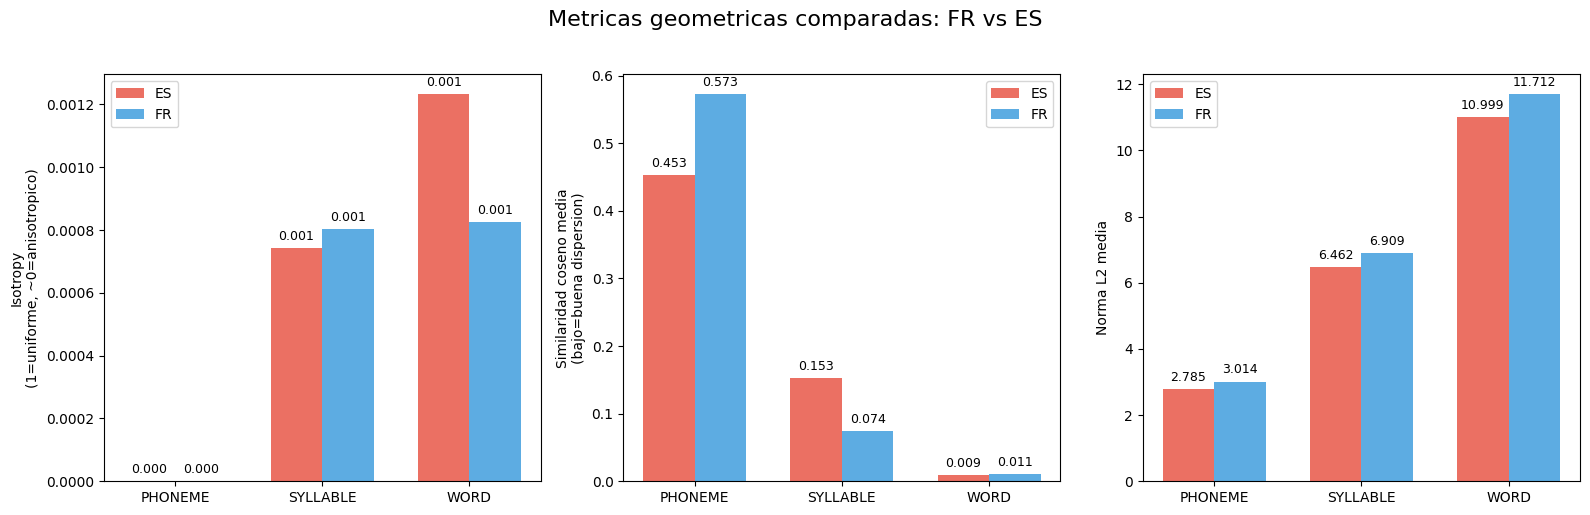

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ("isotropy", "Isotropy\n(1=uniforme, ~0=anisotropico)"),
    ("cos_sim_mean", "Similaridad coseno media\n(bajo=buena dispersion)"),
    ("norm_mean", "Norma L2 media"),
]

for idx, (metric, ylabel) in enumerate(metrics):
    ax = axes[idx]
    levels = ["phoneme", "syllable", "word"]
    es_vals = [all_stats[f"{lv}_es"][metric] for lv in levels]
    fr_vals = [all_stats[f"{lv}_fr"][metric] for lv in levels]
    
    x = np.arange(len(levels))
    width = 0.35
    ax.bar(x - width/2, es_vals, width, color="#e74c3c", label="ES", alpha=0.8)
    ax.bar(x + width/2, fr_vals, width, color="#3498db", label="FR", alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([lv.upper() for lv in levels])
    ax.set_ylabel(ylabel)
    ax.legend()
    
    # Add value labels
    for i, (v_es, v_fr) in enumerate(zip(es_vals, fr_vals)):
        ax.text(i - width/2, v_es + ax.get_ylim()[1]*0.02, f"{v_es:.3f}", ha="center", fontsize=9)
        ax.text(i + width/2, v_fr + ax.get_ylim()[1]*0.02, f"{v_fr:.3f}", ha="center", fontsize=9)

plt.suptitle("Metricas geometricas comparadas: FR vs ES", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("geometric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Explained variance: espectro de valores propios

Cuantas dimensiones "efectivas" usa cada espacio? Si pocas dimensiones concentran la varianza, el espacio es de baja dimensionalidad efectiva.

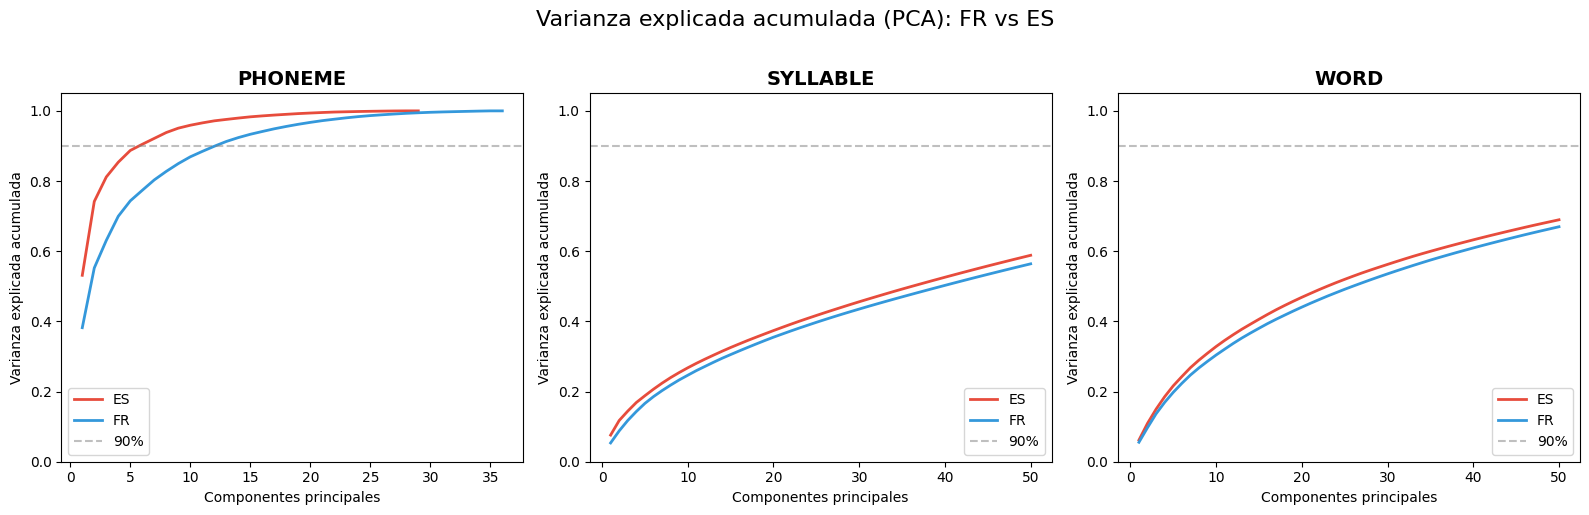

In [7]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    for lang, color, label in [("es", "#e74c3c", "ES"), ("fr", "#3498db", "FR")]:
        lang_filter = lang if level == "phoneme" else None
        _, vectors = get_filtered_vectors(models[level][lang], lang=lang_filter)
        
        n_components = min(50, vectors.shape[0], vectors.shape[1])
        pca = PCA(n_components=n_components)
        pca.fit(vectors)
        
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        ax.plot(range(1, n_components + 1), cumvar, color=color, label=label, linewidth=2)
    
    ax.set_xlabel("Componentes principales")
    ax.set_ylabel("Varianza explicada acumulada")
    ax.set_title(f"{level.upper()}", fontsize=14, fontweight="bold")
    ax.axhline(y=0.9, color="gray", linestyle="--", alpha=0.5, label="90%")
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.suptitle("Varianza explicada acumulada (PCA): FR vs ES", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Distribucion de distancias euclidianas intra-espacio

Que tan dispersos estan los vectores dentro de cada espacio.

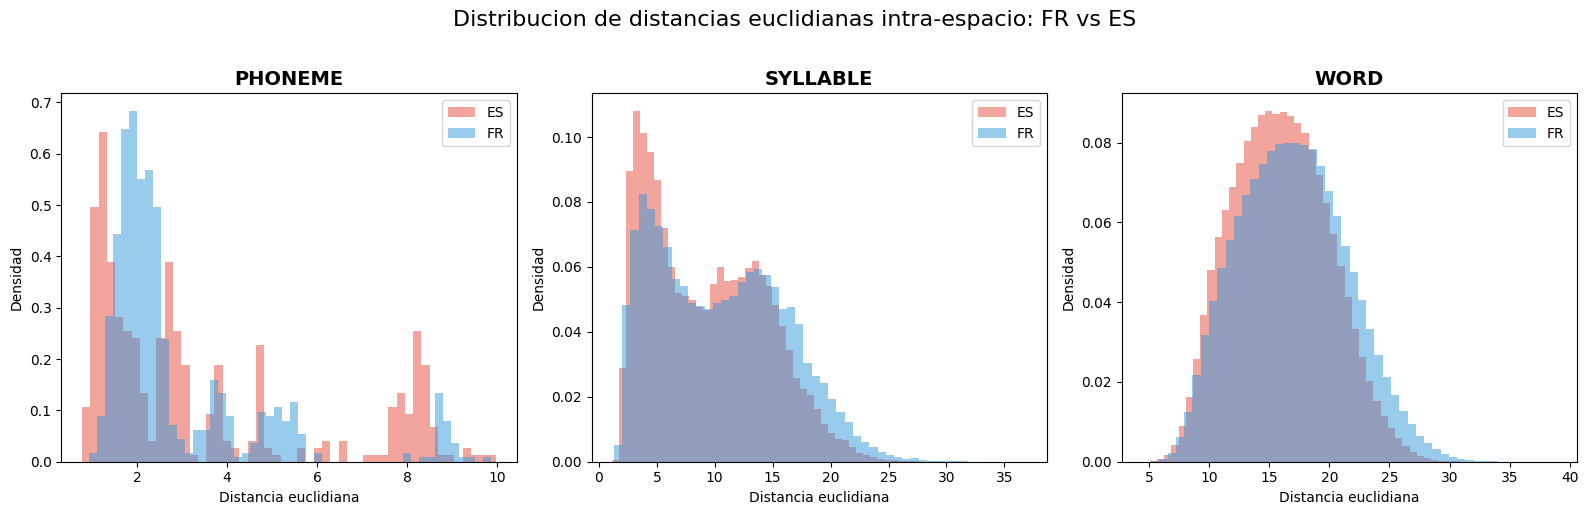

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    for lang, color, label in [("es", "#e74c3c", "ES"), ("fr", "#3498db", "FR")]:
        key = f"{level}_{lang}"
        euc = all_distributions[key]["euc_dists"]
        ax.hist(euc, bins=50, alpha=0.5, color=color, label=label, density=True)
    
    ax.set_xlabel("Distancia euclidiana")
    ax.set_ylabel("Densidad")
    ax.set_title(f"{level.upper()}", fontsize=14, fontweight="bold")
    ax.legend()

plt.suptitle("Distribucion de distancias euclidianas intra-espacio: FR vs ES", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("euclidean_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Dimensionalidad efectiva

Numero de componentes PCA necesarios para explicar 80% y 90% de la varianza.

In [9]:
dim_rows = []
for level in ("phoneme", "syllable", "word"):
    for lang in ("es", "fr"):
        lang_filter = lang if level == "phoneme" else None
        _, vectors = get_filtered_vectors(models[level][lang], lang=lang_filter)
        
        n_components = min(vectors.shape[0], vectors.shape[1])
        pca = PCA(n_components=n_components)
        pca.fit(vectors)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        
        dim_80 = np.searchsorted(cumvar, 0.80) + 1
        dim_90 = np.searchsorted(cumvar, 0.90) + 1
        dim_95 = np.searchsorted(cumvar, 0.95) + 1
        
        dim_rows.append({
            "Nivel": level,
            "Idioma": lang.upper(),
            "Total dims": vectors.shape[1],
            "Tokens": vectors.shape[0],
            "Dims 80%": dim_80,
            "Dims 90%": dim_90,
            "Dims 95%": dim_95,
            "Effective ratio 90%": f"{dim_90/vectors.shape[1]:.1%}",
        })

dim_df = pd.DataFrame(dim_rows)
dim_df

,Nivel,Idioma,Total dims,Tokens,Dims 80%,Dims 90%,Dims 95%,Effective ratio 90%
0,phoneme,ES,150,29,3,6,9,4.0%
1,phoneme,FR,150,36,7,13,18,8.7%
2,syllable,ES,150,9848,92,118,132,78.7%
3,syllable,FR,150,12433,97,121,134,80.7%
4,word,ES,150,37291,75,106,126,70.7%
5,word,FR,150,37269,79,109,127,72.7%
